In [56]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rishidamarla/heart-disease-prediction/Heart_Disease_Prediction.csv


In [57]:
hd = pd.read_csv('/kaggle/input/datasets/rishidamarla/heart-disease-prediction/Heart_Disease_Prediction.csv')

In [59]:
hd.shape

(270, 14)

In [60]:
hd.info

<bound method DataFrame.info of      Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0     70    1                4  130          322             0            2   
1     67    0                3  115          564             0            2   
2     57    1                2  124          261             0            0   
3     64    1                4  128          263             0            0   
4     74    0                2  120          269             0            2   
..   ...  ...              ...  ...          ...           ...          ...   
265   52    1                3  172          199             1            0   
266   44    1                2  120          263             0            0   
267   56    0                2  140          294             0            2   
268   57    1                4  140          192             0            0   
269   67    1                4  160          286             0            2   

     Max HR  Exerci

In [61]:
print(hd.isnull().sum())

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


In [62]:
print(hd.describe())

              Age         Sex  Chest pain type          BP  Cholesterol  \
count  270.000000  270.000000       270.000000  270.000000   270.000000   
mean    54.433333    0.677778         3.174074  131.344444   249.659259   
std      9.109067    0.468195         0.950090   17.861608    51.686237   
min     29.000000    0.000000         1.000000   94.000000   126.000000   
25%     48.000000    0.000000         3.000000  120.000000   213.000000   
50%     55.000000    1.000000         3.000000  130.000000   245.000000   
75%     61.000000    1.000000         4.000000  140.000000   280.000000   
max     77.000000    1.000000         4.000000  200.000000   564.000000   

       FBS over 120  EKG results      Max HR  Exercise angina  ST depression  \
count    270.000000   270.000000  270.000000       270.000000      270.00000   
mean       0.148148     1.022222  149.677778         0.329630        1.05000   
std        0.355906     0.997891   23.165717         0.470952        1.14521   
min 

In [63]:
print(hd.head)

<bound method NDFrame.head of      Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0     70    1                4  130          322             0            2   
1     67    0                3  115          564             0            2   
2     57    1                2  124          261             0            0   
3     64    1                4  128          263             0            0   
4     74    0                2  120          269             0            2   
..   ...  ...              ...  ...          ...           ...          ...   
265   52    1                3  172          199             1            0   
266   44    1                2  120          263             0            0   
267   56    0                2  140          294             0            2   
268   57    1                4  140          192             0            0   
269   67    1                4  160          286             0            2   

     Max HR  Exercise

In [64]:
X = hd.drop(['Heart Disease'],axis=1)
y = hd['Heart Disease']

In [65]:
y = y.map({
    "Absence":0,
     "Presence":1
})

In [66]:
print(y.unique())

[1 0]


In [67]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,test_size=0.2)

In [68]:
from xgboost import XGBClassifier 
model = XGBClassifier(n_estimators = 100,random_state = 0,learning_rate = 0.5)

In [69]:
from sklearn.pipeline import Pipeline
my_pipeline = Pipeline(
             [("model",model)]
)

In [70]:
my_pipeline.fit(X_train,y_train)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.5,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
 predictions = my_pipeline.predict(X_test)

In [71]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,predictions)
print(accuracy)

0.6111111111111112


In [72]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,predictions)
print(cm)

[[20  8]
 [13 13]]


In [86]:
from sklearn.metrics import precision_score
pc= precision_score(y_test,predictions)
print(f"Precision : {pc:.3f}")

Precision : 0.619


In [74]:
from sklearn.metrics import recall_score
rs= recall_score(y_test,predictions)
print(rs)

0.5


In [75]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test,predictions)
print(f1)

0.5531914893617021


In [76]:
from sklearn.metrics import roc_auc_score
probs = my_pipeline.predict_proba(X_test)
print(probs[:5])

[[9.9879229e-01 1.2076838e-03]
 [9.9949074e-01 5.0928758e-04]
 [9.7101068e-01 2.8989300e-02]
 [7.6887500e-01 2.3112498e-01]
 [9.9978024e-01 2.1973455e-04]]


In [77]:
roc = roc_auc_score(
       y_test,
       probs[:,1]
        )
print(roc)

0.8571428571428572


In [78]:
trained_model = my_pipeline.named_steps['model']
print(trained_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)


In [79]:
trained_model.feature_importances_

array([0.04091508, 0.06324004, 0.12587862, 0.03118369, 0.02699641,
       0.01425905, 0.02393557, 0.02818707, 0.05209439, 0.08207506,
       0.05277687, 0.11113364, 0.34732452], dtype=float32)

In [80]:
feature_df = pd.DataFrame({
    "Feature":X.columns,
    "Importance":trained_model.feature_importances_
})
feature_df


,Feature,Importance
0,Age,0.040915
1,Sex,0.063240
2,Chest pain type,0.125879
3,BP,0.031184
4,Cholesterol,0.026996
5,FBS over 120,0.014259
6,EKG results,0.023936
7,Max HR,0.028187
8,Exercise angina,0.052094
9,ST depression,0.082075


In [81]:
feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)
feature_df.head

<bound method NDFrame.head of                     Feature  Importance
12                 Thallium    0.347325
2           Chest pain type    0.125879
11  Number of vessels fluro    0.111134
9             ST depression    0.082075
1                       Sex    0.063240
10              Slope of ST    0.052777
8           Exercise angina    0.052094
0                       Age    0.040915
3                        BP    0.031184
7                    Max HR    0.028187
4               Cholesterol    0.026996
6               EKG results    0.023936
5              FBS over 120    0.014259>

<Axes: xlabel='Importance', ylabel='Feature'>

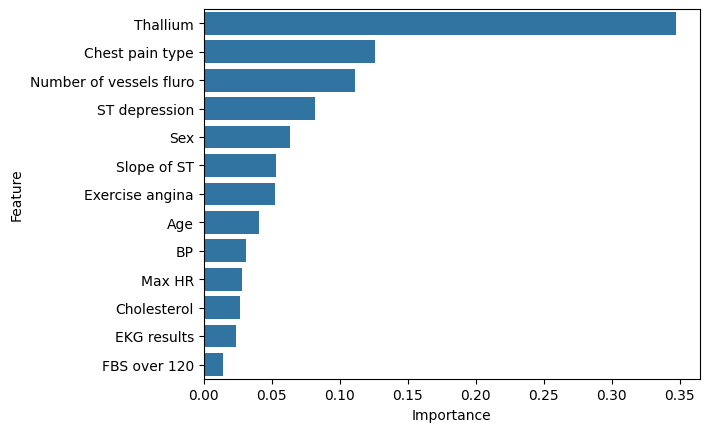

In [83]:
import seaborn as sns 
sns.barplot(
    x = "Importance",
    y=feature_df["Feature"],
    data = feature_df
)

Text(50.722222222222214, 0.5, 'Actual')

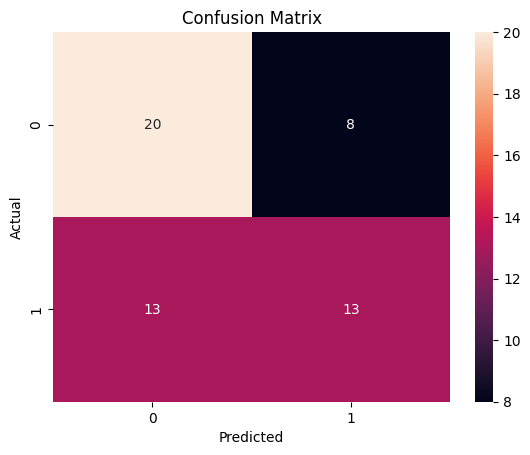

In [84]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt ='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

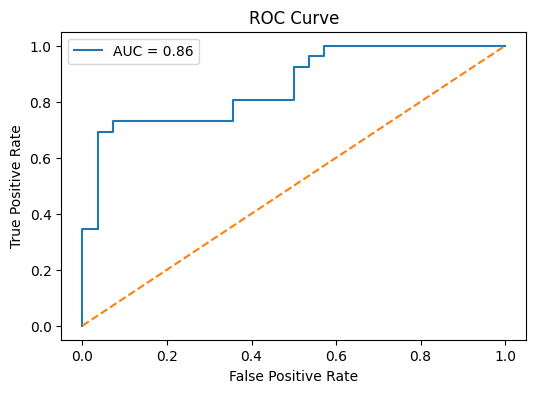

In [85]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, probs[:, 1])

auc = roc_auc_score(y_test, probs[:, 1])
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

 Conclusion

This project successfully predicts the presence or absence of heart disease using the XGBoost classifier.

 Results

- Accuracy: **75%**
- Precision: **74.19%**
- Recall: **85.19%**
- ROC-AUC Score: **0.92**

 Key Findings

- Chest Pain Type was the most important feature.
- Thallium and Number of Vessels Fluoroscopy also contributed significantly.
- The ROC-AUC score of **0.92** indicates excellent discrimination between the two classes.

 Future Improvements

- Hyperparameter tuning
- Cross-validation
- SHAP Explainability
- Model deployment using Streamlit